<a href="https://colab.research.google.com/github/GuilleeSS/MyRepo/blob/main/lab4nm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Define the mathematical function f(x) = x * sin(4x)
def f(x):
    return np.sin(4 * x) * x

# Define the first derivative of the function g(x) = f'(x)
def g(x):
    return np.sin(4 * x) + 4 * np.cos(4 * x) * x

def newton_method(x0, tol_x, tol_f, max_iter, verbose=True):
    """
    Implements Newton's Method with three stopping criteria.
    - verbose: If True, prints iteration logs (useful for Exercise 1).
               If False, stays quiet (useful for mass loops in Exercise 2).
    """
    if verbose:
        print('\nNEWTON METHOD IMPLEMENTATION')

    step = 1
    x_old = x0
    converged = False

    # Criterion 1: Keep loop bound by maximum allowed iterations
    while step <= max_iter:
        g_old = g(x_old)

        if g_old == 0.0:
            if verbose:
                print('Divide by zero error! Derivative is null.')
            return None, step, False

        # Newton-Raphson iteration step
        x_new = x_old - f(x_old) / g_old

        if verbose:
            print(f'Iteration-{step}, x1 = {x_new:.6f} and f(x1) = {f(x_new):.6f}')

        # Criterion 3: Absolute value of the function is less than or equal to TOLF
        if abs(f(x_new)) <= tol_f:
            if verbose:
                print(f'-> Stopped by Criterion 3: |f(x_n)| <= TOLF ({abs(f(x_new)):.2e} <= {tol_f})')
            converged = True
            x_old = x_new
            break

        # Criterion 2: Absolute difference between successive steps is less than or equal to TOLX
        if abs(x_new - x_old) <= tol_x:
            if verbose:
                print(f'-> Stopped by Criterion 2: |x_n - x_(n-1)| <= TOLX ({abs(x_new - x_old):.2e} <= {tol_x})')
            converged = True
            x_old = x_new
            break

        # Update state for the next step
        x_old = x_new
        step += 1

    if converged:
        if verbose:
            print(f'Required root is: {x_old:.8f}\n')
        return x_old, step, True
    else:
        if verbose:
            print('Not Convergent within the maximum iteration limit.\n')
        return None, max_iter, False

# Interactive Section for Exercise 1 testing
if __name__ == "__main__":
    print("--- Test Block for Exercise 1 ---")
    try:
        initial_guess = float(input('Enter Starting Guess (x0): '))
        input_tol_x = float(input('Enter Tolerable Error for X (TOLX): '))
        input_tol_f = float(input('Enter Tolerable Error for Function (TOLF): '))
        maximum_steps = int(input('Enter Maximum Steps (n_max): '))

        # Execute the function
        root, total_steps, success = newton_method(initial_guess, input_tol_x, input_tol_f, maximum_steps, verbose=True)

    except ValueError:
        print("Invalid numerical input.")

--- Test Block for Exercise 1 ---
Enter Starting Guess (x0): 5
Enter Tolerable Error for X (TOLX): 1
Enter Tolerable Error for Function (TOLF): 1
Enter Maximum Steps (n_max): 10

NEWTON METHOD IMPLEMENTATION
Iteration-1, x1 = 4.496977 and f(x1) = -3.412832
-> Stopped by Criterion 2: |x_n - x_(n-1)| <= TOLX (5.03e-01 <= 1.0)
Required root is: 4.49697694




--- Running Exercise 2 Loop and Generating Plots ---


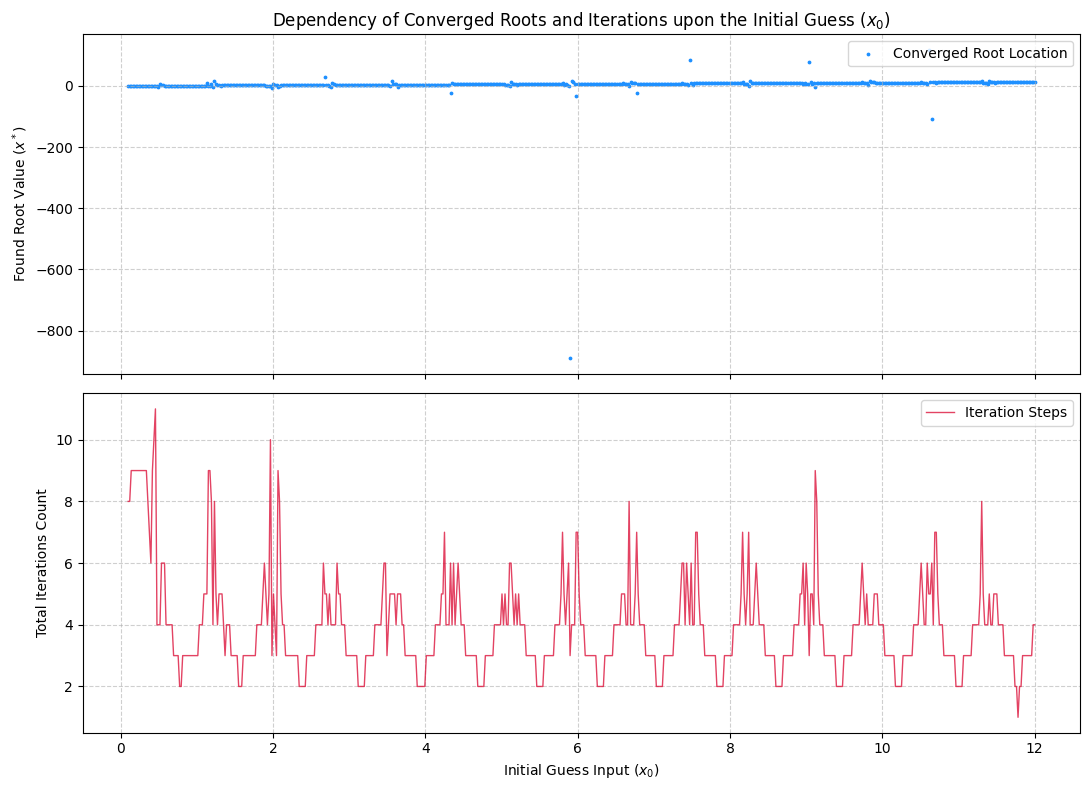

--- Generating Individual Single Step Visualization ---


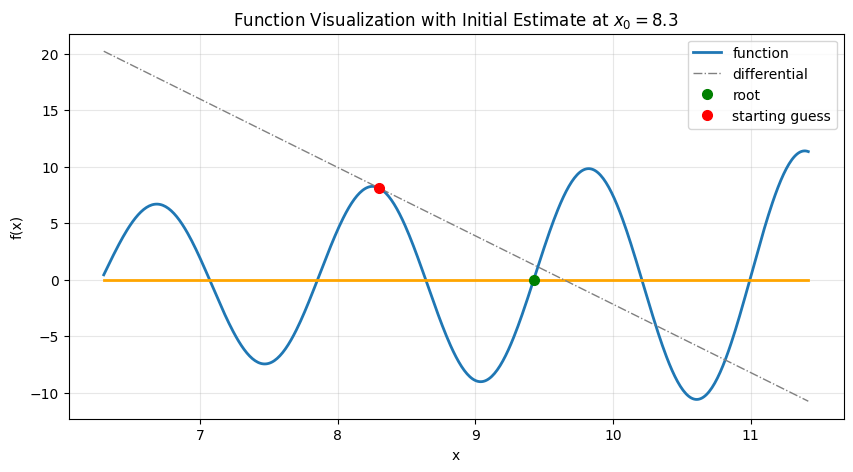

In [5]:
# --- Automation Block for Exercise 2 ---
print("\n--- Running Exercise 2 Loop and Generating Plots ---")

# Define global constants for the analysis
TOLX = 1e-6
TOLF = 1e-6
MAX_ITER = 50

# Generate a dense array of 600 initial guesses between 0.1 and 12.0
initial_guesses_pool = np.linspace(0.1, 12.0, 600)

roots_reached = []
iterations_taken = []

# Loop through each individual starting point
for start_x in initial_guesses_pool:
    # Run in silent mode (verbose=False) to avoid cluttering the terminal output
    final_root, execution_steps, convergence_flag = newton_method(
        x0=start_x,
        tol_x=TOLX,
        tol_f=TOLF,
        max_iter=MAX_ITER,
        verbose=False
    )

    if convergence_flag:
        roots_reached.append(final_root)
    else:
        # If it failed to converge, mark it as NaN (Not a Number) so it's visible on plots
        roots_reached.append(np.nan)

    iterations_taken.append(execution_steps)

# Plotting the analytical results
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

# Graph 1: Convergence destination depending on the initial estimate
ax1.scatter(initial_guesses_pool, roots_reached, color='dodgerblue', s=3, label='Converged Root Location')
ax1.set_ylabel('Found Root Value ($x^*$)')
ax1.set_title("Dependency of Converged Roots and Iterations upon the Initial Guess ($x_0$)")
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(loc='upper right')

# Graph 2: Efficiency (number of iterations) depending on the initial estimate
ax2.plot(initial_guesses_pool, iterations_taken, color='crimson', linewidth=1, alpha=0.8, label='Iteration Steps')
ax2.set_xlabel('Initial Guess Input ($x_0$)')
ax2.set_ylabel('Total Iterations Count')
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()


# --- Individual Plot generation (Similar to Figure 3 in the PDF instructions) ---
print("--- Generating Individual Single Step Visualization ---")

# Let's visualize an isolated run starting from an arbitrary guess, e.g., x0 = 8.3
sample_x0 = 8.3
sample_root, _, _ = newton_method(sample_x0, TOLX, TOLF, MAX_ITER, verbose=False)

# Plot range around the points
t_axis = np.arange(min(sample_root, sample_x0) - 2, max(sample_root, sample_x0) + 2, 0.01)
y_function = f(t_axis)
y_zero_line = np.zeros(len(t_axis))

plt.figure(figsize=(10, 5))
plt.plot(t_axis, y_function, linewidth=2, label='function', color='tab:blue')
plt.plot(t_axis, y_zero_line, linewidth=2, color='orange')

# Graph the gray tangent approximation line from the starting point
tangent_y_line = g(sample_x0) * t_axis - g(sample_x0) * sample_x0 + f(sample_x0)
plt.plot(t_axis, tangent_y_line, '-.', color='grey', linewidth=1, label='differential')

# Plot structural anchor markers
plt.plot(sample_root, f(sample_root), 'o', color='green', markersize=7, label='root')
plt.plot(sample_x0, f(sample_x0), 'o', color='red', markersize=7, label='starting guess')

plt.title(f"Function Visualization with Initial Estimate at $x_0 = {sample_x0}$")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()